# Goal

Sweep the DSB-normalized UMI threshold used to call oBC barcodes on a cell and look
at how the singlet / doublet / multiplet / uncalled tradeoff curve moves, the SIG02
analog of SIG13's `01_barcode_calling_comparison.ipynb` Part A. SIG02's pooled
18-barcode `bc` modality (`{gene}_BC{n}`, 1-4 replicate barcodes per cargo gene, no
round1/round2 structure) has no per-cell ground-truth label, so this is a descriptive
sweep of the calling tradeoff rather than an ROC/AUC-style classification (out of
scope for SIG02 -- see `processing/scanpy_processing_SIG02.ipynb`).

A "feature call" here means: for a given DSB threshold `t`, a barcode is "called" on
a cell if its DSB-normalized count is `>= t`. A cell is a **singlet** if exactly one
barcode is called, a **doublet** if exactly two, a **multiplet** if more than two, and
**uncalled** if none clear the threshold.

## Packages

In [1]:
import os
import numpy as np
import pandas as pd
import muon as mu

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['text.usetex']  = False
sns.set_theme(style="ticks")

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


## Paths

In [2]:
# Repo-relative paths: inputs from imports_stable/, outputs to analysis_outs/
from pathlib import Path
_here = Path.cwd().resolve()
REPO_DIR = str(next(p for p in [_here, *_here.parents] if (p / "imports_stable").is_dir()))
IMPORTS_DIR = f"{REPO_DIR}/imports_stable"
OUTS_DIR = f"{REPO_DIR}/analysis_outs/01_barcode_comparison_signalseq_SIG02_SIG03"

SCANPY_OUTS = f"{IMPORTS_DIR}/SIG02/scanpy_outs"
FULL_H5MU = os.path.join(SCANPY_OUTS, "SIG02_full.h5mu")

ANALYSIS_OUTS = OUTS_DIR
PLOT_DIR = os.path.join(ANALYSIS_OUTS, "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

## Load data

`bc.X` is the DSB-normalized oBC modality (identical to `bc.layers['dsb']`); `bc.layers['counts']`
holds the raw UMI counts.

In [3]:
mdata = mu.read_h5mu(FULL_H5MU)
bc = mdata.mod["bc"]
bc

/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/data1/rudenska/EYW/mamba_envs/scanpy_standard2/lib/python3.14/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


AnnData object with n_obs × n_vars = 22360 × 18
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'
    layers: 'counts', 'dsb'

# Barcode Calling Rates Across DSB Cutoffs

Sweep the DSB threshold and, at each value, recompute how many cells are singlets,
doublets, multiplets, or uncalled.

## Feature-calling helper

In [4]:
def call_categories(X, threshold):
    """
    Per-cell call category at a given DSB threshold.

    Parameters:
    - X: array, cells x barcodes DSB-normalized matrix
    - threshold: float, minimum DSB score to call a barcode on a cell

    Returns:
    - num_features: int array, number of barcodes called per cell
    """
    return (X >= threshold).sum(axis=1)

## Sweep cutoffs

SIG02's DSB scores are much lower-dynamic-range than SIG13's (background sits near
DSB ~1, called barcodes extend out to ~30), so the sweep grid is 1-20 rather than
SIG13's 1-10. For each threshold, recompute the singlet/doublet/multiplet/uncalled
counts as fractions and counts of *all* cells in `bc`.

In [7]:
CAT_COLORS = {"singlet": "C0", "doublet": "C1", "multiplet": "C3", "uncalled": "C4"}
CAT_ORDER = ["singlet", "doublet", "multiplet", "uncalled"]
CUTOFFS = list(range(1, 11))

X = np.asarray(bc.X)
n_total = bc.n_obs

cutoff_rows = []
for t in CUTOFFS:
    nf = call_categories(X, t)
    singlet = int((nf == 1).sum())
    doublet = int((nf == 2).sum())
    multiplet = int((nf > 2).sum())
    uncalled = int((nf == 0).sum())
    cutoff_rows.append({
        "cutoff": t,
        "singlet": singlet,
        "doublet": doublet,
        "multiplet": multiplet,
        "uncalled": uncalled,
        "singlet_pct": singlet / n_total * 100,
        "doublet_pct": doublet / n_total * 100,
        "multiplet_pct": multiplet / n_total * 100,
        "uncalled_pct": uncalled / n_total * 100,
    })

cutoff_df = pd.DataFrame(cutoff_rows)
cutoff_df.to_csv(f"{ANALYSIS_OUTS}/barcode_calling_rate_vs_cutoff_SIG02.csv", index=False)
cutoff_df

,cutoff,singlet,doublet,multiplet,uncalled,singlet_pct,doublet_pct,multiplet_pct,uncalled_pct
0,1,7072,1723,369,13196,31.627907,7.705725,1.650268,59.016100
1,2,7072,1723,369,13196,31.627907,7.705725,1.650268,59.016100
2,3,6590,1421,280,14069,29.472272,6.355098,1.252236,62.920394
3,4,6514,1364,254,14228,29.132379,6.100179,1.135957,63.631485
4,5,5842,1050,169,15299,26.127013,4.695886,0.755814,68.421288
5,6,4669,660,70,16961,20.881038,2.951699,0.313059,75.854204
6,7,4249,561,57,17493,19.002683,2.508945,0.254919,78.233453
7,8,3759,390,34,18177,16.811270,1.744186,0.152057,81.292487
8,9,3339,315,25,18681,14.932916,1.408766,0.111807,83.546512
9,10,2901,245,14,19200,12.974061,1.095707,0.062612,85.867621


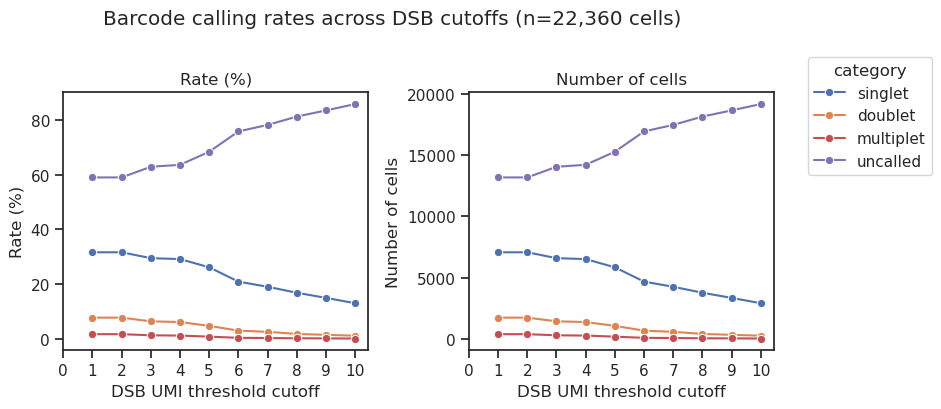

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True)

pct_order = [f"{c}_pct" for c in CAT_ORDER]
pct_palette = {f"{c}_pct": CAT_COLORS[c] for c in CAT_ORDER}

# --- Panel 1: percentages ---
plot_df_pct = cutoff_df.melt(
    id_vars="cutoff", value_vars=pct_order,
    var_name="category", value_name="rate_pct"
)
sns.lineplot(data=plot_df_pct, x="cutoff", y="rate_pct", hue="category", marker="o",
             hue_order=pct_order, palette=pct_palette, ax=axes[0], legend=False)
axes[0].set_xlabel("DSB UMI threshold cutoff")
axes[0].set_ylabel("Rate (%)")
axes[0].set_title("Rate (%)")
axes[0].set_xticks([1,2,3,4,5,6,7,8,9,10])

# --- Panel 2: counts ---
plot_df_num = cutoff_df.melt(
    id_vars="cutoff", value_vars=CAT_ORDER,
    var_name="category", value_name="cell_num"
)
sns.lineplot(data=plot_df_num, x="cutoff", y="cell_num", hue="category", marker="o",
              hue_order=CAT_ORDER, palette=CAT_COLORS, ax=axes[1])
axes[1].set_xlabel("DSB UMI threshold cutoff")
axes[1].set_ylabel("Number of cells")
axes[1].set_title("Number of cells")
axes[1].set_xticks([0,1,2,3,4,5,6,7,8,9,10])
# Single shared legend on the right, using panel 2's handles
handles, labels = axes[1].get_legend_handles_labels()
axes[1].get_legend().remove()
fig.legend(handles, labels, bbox_to_anchor=(1.02, 0.9), loc="upper left",
           borderaxespad=0., title="category")

fig.suptitle(f"Barcode calling rates across DSB cutoffs (n={n_total:,} cells)", y=1.02)
plt.tight_layout()
plt.savefig(f"{PLOT_DIR}/barcode_calling_rate_vs_cutoff_SIG02.pdf", bbox_inches="tight")
plt.show()